In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('/content/uber.csv')
data.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [ ]:
list(data)

['Unnamed: 0',
 'key',
 'fare_amount',
 'pickup_datetime',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count']

In [ ]:
data.rename(columns={'Unnamed: 0':'ID'},inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ID                 200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [ ]:
data['pickup_datetime']=pd.to_datetime(data['pickup_datetime'])

data['hour'] = data['pickup_datetime'].dt.hour
data['day'] = data['pickup_datetime'].dt.day
data['month'] = data['pickup_datetime'].dt.month
data['year'] = data['pickup_datetime'].dt.year
data['day_of_week'] = data['pickup_datetime'].dt.dayofweek
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   ID                 200000 non-null  int64              
 1   key                200000 non-null  object             
 2   fare_amount        200000 non-null  float64            
 3   pickup_datetime    200000 non-null  datetime64[ns, UTC]
 4   pickup_longitude   200000 non-null  float64            
 5   pickup_latitude    200000 non-null  float64            
 6   dropoff_longitude  199999 non-null  float64            
 7   dropoff_latitude   199999 non-null  float64            
 8   passenger_count    200000 non-null  int64              
 9   hour               200000 non-null  int32              
 10  day                200000 non-null  int32              
 11  month              200000 non-null  int32              
 12  year               200000 non-

In [ ]:
data.groupby(['passenger_count']).count()

,ID,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,hour,day,month,year,day_of_week
passenger_count,,,,,,,,,,,,,
0,709,709,709,709,709,709,708,708,709,709,709,709,709
1,138425,138425,138425,138425,138425,138425,138425,138425,138425,138425,138425,138425,138425
2,29428,29428,29428,29428,29428,29428,29428,29428,29428,29428,29428,29428,29428
3,8881,8881,8881,8881,8881,8881,8881,8881,8881,8881,8881,8881,8881
4,4276,4276,4276,4276,4276,4276,4276,4276,4276,4276,4276,4276,4276
5,14009,14009,14009,14009,14009,14009,14009,14009,14009,14009,14009,14009,14009
6,4271,4271,4271,4271,4271,4271,4271,4271,4271,4271,4271,4271,4271
208,1,1,1,1,1,1,1,1,1,1,1,1,1


In [ ]:
data=data[(data['passenger_count'])<7]

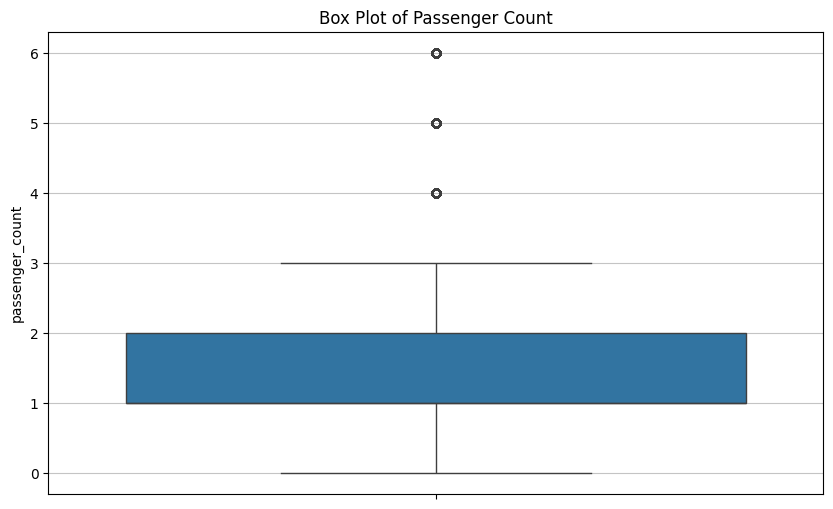

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=data['passenger_count'])
plt.title('Box Plot of Passenger Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
data['passenger_count'] = data['passenger_count'].mask(data['passenger_count']>3, 3)
data['passenger_count'] = data['passenger_count'].mask(data['passenger_count']<1, 1)

display(data.groupby(['passenger_count']).count())
data.shape

,ID,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,hour,day,month,year,day_of_week
passenger_count,,,,,,,,,,,,,
1,139134,139134,139134,139134,139134,139134,139133,139133,139134,139134,139134,139134,139134
2,29428,29428,29428,29428,29428,29428,29428,29428,29428,29428,29428,29428,29428
3,31437,31437,31437,31437,31437,31437,31437,31437,31437,31437,31437,31437,31437


(199999, 14)

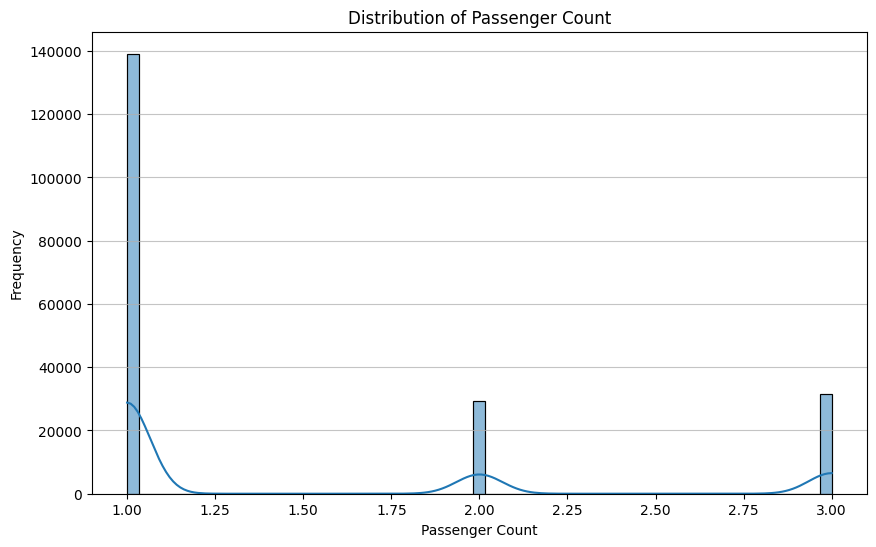

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['passenger_count'],  kde=True)
plt.title('Distribution of Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
data.describe()

,ID,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year,day_of_week
count,1.999990e+05,199999.000000,199999.000000,199999.000000,199998.000000,199998.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,2.771246e+07,11.359954,-72.527631,39.935881,-72.525285,39.923886,1.461512,13.491362,15.704609,6.281766,2011.742449,3.048435
std,1.601385e+07,9.901801,11.437815,7.720558,13.117440,6.794846,0.750262,6.515536,8.687387,3.438910,1.856398,1.946946
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,1.000000,0.000000,1.000000,1.000000,2009.000000,0.000000
25%,1.382534e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000,9.000000,8.000000,3.000000,2010.000000,1.000000
50%,2.774524e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000,14.000000,16.000000,6.000000,2012.000000,3.000000
75%,4.155535e+07,12.500000,-73.967154,40.767158,-73.963659,40.768001,2.000000,19.000000,23.000000,9.000000,2013.000000,5.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,3.000000,23.000000,31.000000,12.000000,2015.000000,6.000000


In [ ]:
data=data[(data['pickup_latitude']>=-90) & (data['pickup_latitude']<=90)]
data=data[(data['dropoff_latitude']>=-90) & (data['dropoff_latitude']<=90)]

data=data[(data['pickup_longitude']>=-180) & (data['pickup_longitude']<=180)]
data=data[(data['dropoff_longitude']>=-180) & (data['dropoff_longitude']<=180)]

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    res = 2 * R * np.arcsin(np.sqrt(a))
    return res

data['distance_km'] = haversine_distance(
    data['pickup_latitude'], data['pickup_longitude'],
    data['dropoff_latitude'], data['dropoff_longitude']
)

# Display the first few rows to verify
print(data[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 'distance_km']].head())
print(f"\nAverage distance: {data['distance_km'].mean():.2f} km")
print(f"\nMaximum distance: {data['distance_km'].max():.2f} km")

   pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude  \
0        40.738354        -73.999817         40.723217         -73.999512   
1        40.728225        -73.994355         40.750325         -73.994710   
2        40.740770        -74.005043         40.772647         -73.962565   
3        40.790844        -73.976124         40.803349         -73.965316   
4        40.744085        -73.925023         40.761247         -73.973082   

   distance_km  
0     1.683323  
1     2.457590  
2     5.036377  
3     1.661683  
4     4.475450  

Average distance: 20.56 km

Maximum distance: 8782.90 km


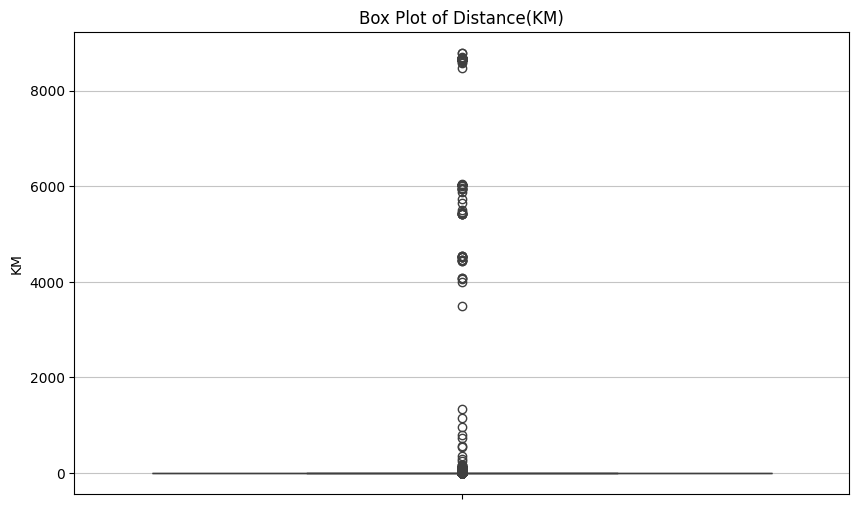

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=data['distance_km'])
plt.title('Box Plot of Distance(KM)')
plt.ylabel('KM')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Calculate IQR for distance_km
Q1 = data['distance_km'].quantile(0.25)
Q3 = data['distance_km'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap outliers at the upper bound (distances are already > 0)
data['distance_km'] = np.where(data['distance_km'] > upper_bound, upper_bound, data['distance_km'])

print(f"IQR: {IQR:.2f}")
print(f"Upper Bound for outliers: {upper_bound:.2f} km")
print(f"Max distance after capping: {data['distance_km'].max():.2f} km")

IQR: 2.66
Upper Bound for outliers: 7.86 km
Max distance after capping: 7.86 km


In [ ]:
data['distance_km'].describe()

,distance_km
count,199986.000000
mean,2.853765
std,2.223296
min,0.000000
25%,1.215180
50%,2.120840
75%,3.874792
max,7.864209


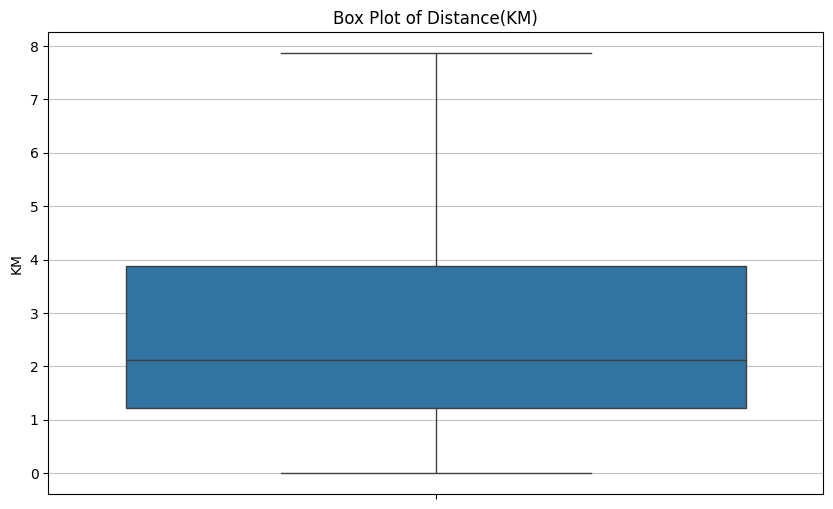

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=data['distance_km'])
plt.title('Box Plot of Distance(KM)')
plt.ylabel('KM')
plt.grid(axis='y', alpha=0.75)
plt.show()

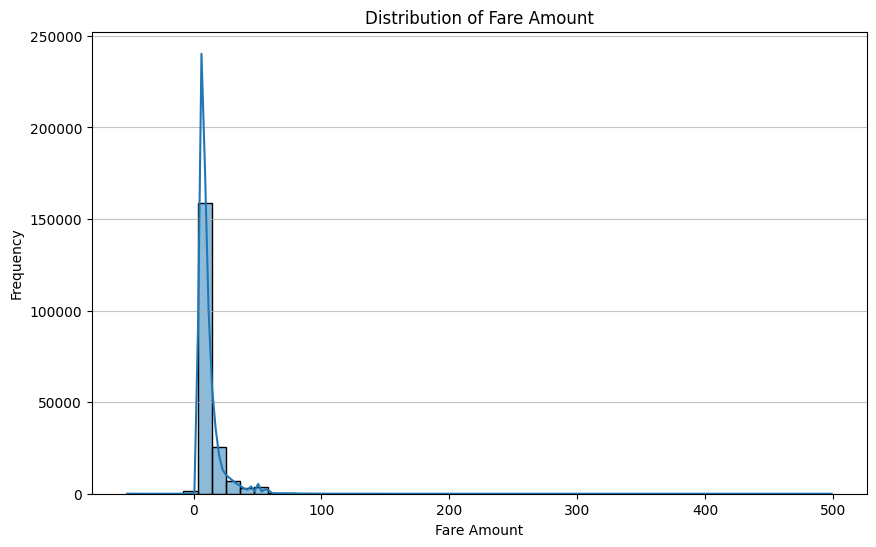

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['fare_amount'], bins=50, kde=True)
plt.title('Distribution of Fare Amount')
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Calculate IQR for fare_amount
Q1 = data['fare_amount'].quantile(0.25)
Q3 = data['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds (standard 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print(f"- IQR: {IQR:.2f}")
print(f"- Upper Bound (Cap): {upper_bound:.2f}")
print(f"- Lower Bound (Cap): {lower_bound:.2f}")

- IQR: 6.50
- Upper Bound (Cap): 22.25
- Lower Bound (Cap): -3.75


In [ ]:
# Cap the outliers
data['fare_amount'] = np.where(data['fare_amount'] > upper_bound, upper_bound,
                              np.where(data['fare_amount'] < lower_bound, lower_bound, data['fare_amount']))

In [ ]:
print(f"- Max fare after capping: {data['fare_amount'].max():.2f}")

- Max fare after capping: 22.25


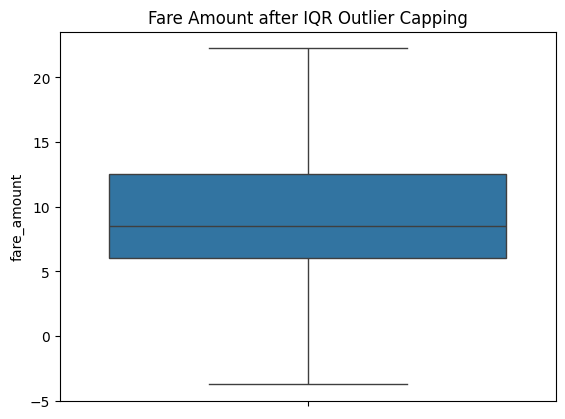

In [ ]:
sns.boxplot(data['fare_amount'])
plt.title('Fare Amount after IQR Outlier Capping')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance_km', y='fare_amount', data=data, alpha=0.3, s=10)
sns.regplot(x='distance_km', y='fare_amount', data=data, scatter=False, color='red')

plt.title('Travel Distance vs Fare Amount')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
df=data.drop(['ID','key','pickup_datetime'],axis=1)
df.shape

In [ ]:
plt.figure(figsize=(10, 6))
corr=df.corr()
sns.heatmap(corr,annot=True, cmap='coolwarm')

In [ ]:
df=pd.get_dummies(df,dtype=int)
df.info()

In [ ]:
df.head()

In [ ]:
X=df.drop('fare_amount',axis=1)
y=df['fare_amount']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42)

# Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
l_pred=reg.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error

print(f'r2_Score: {r2_score(y_test,l_pred)}')
print(f'Mean Absolute Percentage Error: {mean_absolute_percentage_error(y_test,l_pred)}')
print(f'Mean Squared Error: {mean_squared_error(y_test,l_pred)}')

r2_Score: 0.7467735257479129
Mean Absolute Percentage Error: 0.2421700470017779
Mean Squared Error: 7.470392257411023


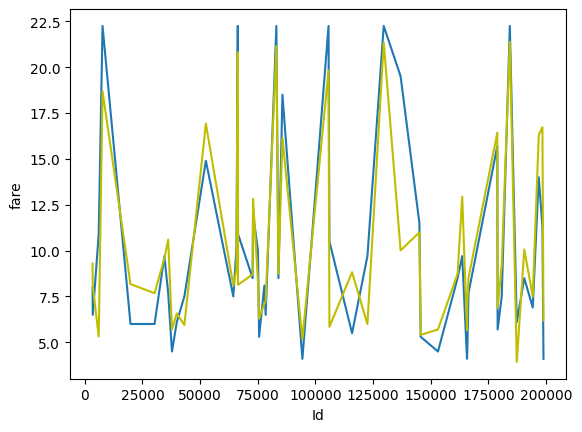

In [ ]:
Results=pd.DataFrame(columns=['Fare','Predicted'])
Results['fare']=y_test
Results['Predicted']=l_pred
Results['Id'] = Results.index
sns.lineplot(x='Id',y='fare',data=Results.head(50))
sns.lineplot(x='Id',y='Predicted',color='y',data=Results.head(50))
plt.show()

# Ridge Regression

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

In [ ]:
alpha = [1e-15,1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1,5,10, 20, 30]
ridge=Ridge()
parameters={'alpha':alpha}
ridge_regressor=GridSearchCV(ridge,parameters)
ridge_regressor.fit(X_train, y_train)

GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1,
                                   5, 10, 20, 30]})

In [ ]:
ridge=Ridge(alpha=30)
ridge.fit(X_train,y_train)
r_pred=ridge.predict(X_test)

In [ ]:
print(f'r2_Score: {r2_score(y_test,r_pred)}')
print(f'Mean Absolute Percentage Error: {mean_absolute_percentage_error(y_test,r_pred)}')
print(f'Mean Squared Error: {mean_squared_error(y_test,r_pred)}')

r2_Score: 0.7467735457439874
Mean Absolute Percentage Error: 0.2421758338688619
Mean Squared Error: 7.4703916675101425


# Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=10, random_state=42)
rf_reg.fit(X_train, y_train)

print(f'Score: {rf_reg.score(X_test, y_test):.4f}')

Score: 0.7976


In [ ]:
rf_pred=rf_reg.predict(X_test)
print(r2_score(y_test,rf_pred))

0.7976071921461184


without coordinates

In [ ]:
features = ['passenger_count', 'hour', 'day', 'month', 'year', 'day_of_week', 'distance_km']
X = data[features]
y = data['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=10, random_state=42)
rf_reg.fit(X_train, y_train)

print(f'Score: {rf_reg.score(X_test, y_test):.4f}')

Score: 0.7510


In [ ]:
rf_pred=rf_reg.predict(X_test)
print(r2_score(y_test,rf_pred))

0.7510286430254755


Search Best Parameters - Hyperparameter Tuning

In [ ]:
reg=RandomForestRegressor()
n_estimators=[25,50,75,100,125,150,175,200] # number of decision tree in the model
criterion=['squared_error']
max_depth=[3,5,10]
parameters={'n_estimators':n_estimators,'criterion':criterion,'max_depth':max_depth}
RFC_reg=GridSearchCV(reg,parameters)
RFC_reg.fit(X_train,y_train)

0.7872249217722217

In [ ]:
best_model = RFC_reg.best_estimator_
test_score = best_model.score(X_test, y_test)
print(f"Final Test R2 Score: {test_score:.4f}")

Final Test R2 Score: 0.7872


/tmp/ipykernel_8926/3957128067.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


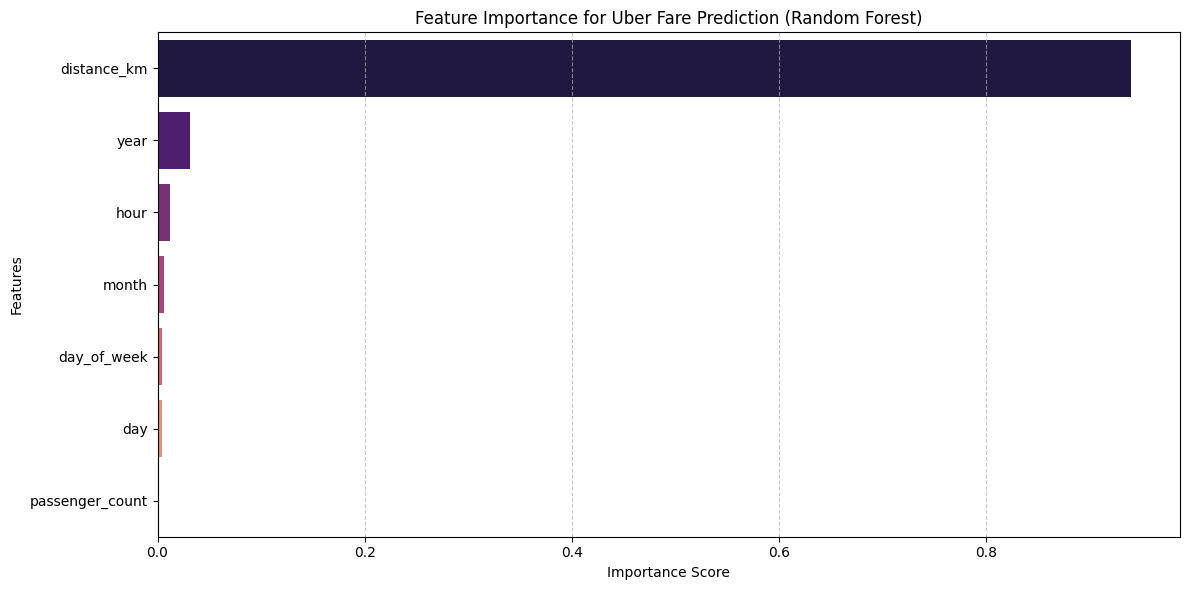

In [ ]:
# Get feature importances from the best model found in GridSearchCV
importances = best_model.feature_importances_
feature_names = features

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance for Uber Fare Prediction (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()